# Quality Prediction of Manufactured Wine Using Physicochemical Properties

## Manufacturing Analytics Project

**Domain:** Quality and Yield Prediction  
**Industry:** Food and Beverage Manufacturing – Wine Industry  
**Dataset:** Wine Quality Dataset – UCI Machine Learning Repository

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv("/content/winequality-red.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
df = pd.read_csv("/content/winequality-red.csv", sep=";")

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Dataset Overview

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1599
Number of columns: 12


In [ ]:
print(df.columns.tolist())

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df.shape

(1599, 12)

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 240


In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## Data Cleaning

The dataset contains no missing values. However, 240 duplicate records were identified. Duplicate records are removed to avoid repeated observations influencing the machine learning models.

In [ ]:
print("Rows before removing duplicates:", df.shape[0])

df = df.drop_duplicates()

print("Rows after removing duplicates:", df.shape[0])

Rows before removing duplicates: 1599
Rows after removing duplicates: 1359


In [ ]:
print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


In [ ]:
print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (1359, 12)


## 5. Exploratory Data Analysis

### 5.1 Distribution of Wine Quality

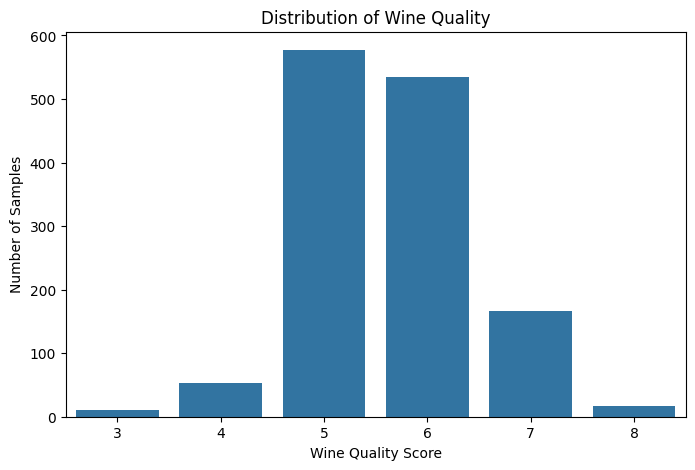

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="quality")

plt.title("Distribution of Wine Quality")
plt.xlabel("Wine Quality Score")
plt.ylabel("Number of Samples")

plt.show()

In [ ]:
df["quality"].value_counts().sort_index()

,count
quality,
3,10
4,53
5,577
6,535
7,167
8,17


### 5.2 Relationship Between Alcohol and Wine Quality

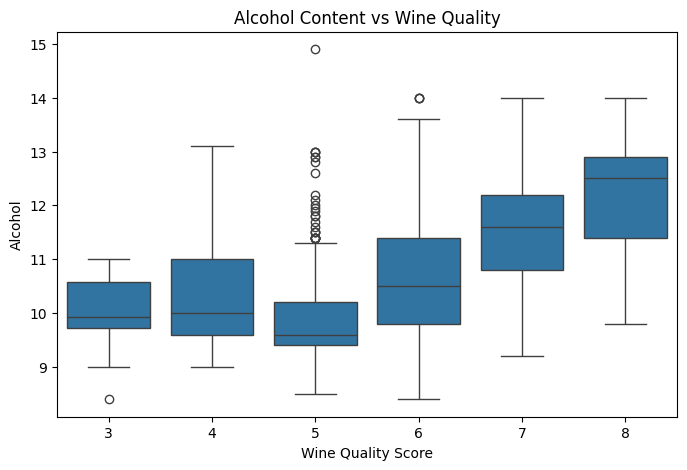

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="quality", y="alcohol")

plt.title("Alcohol Content vs Wine Quality")
plt.xlabel("Wine Quality Score")
plt.ylabel("Alcohol")

plt.show()

### 5.3 Correlation Between Physicochemical Properties

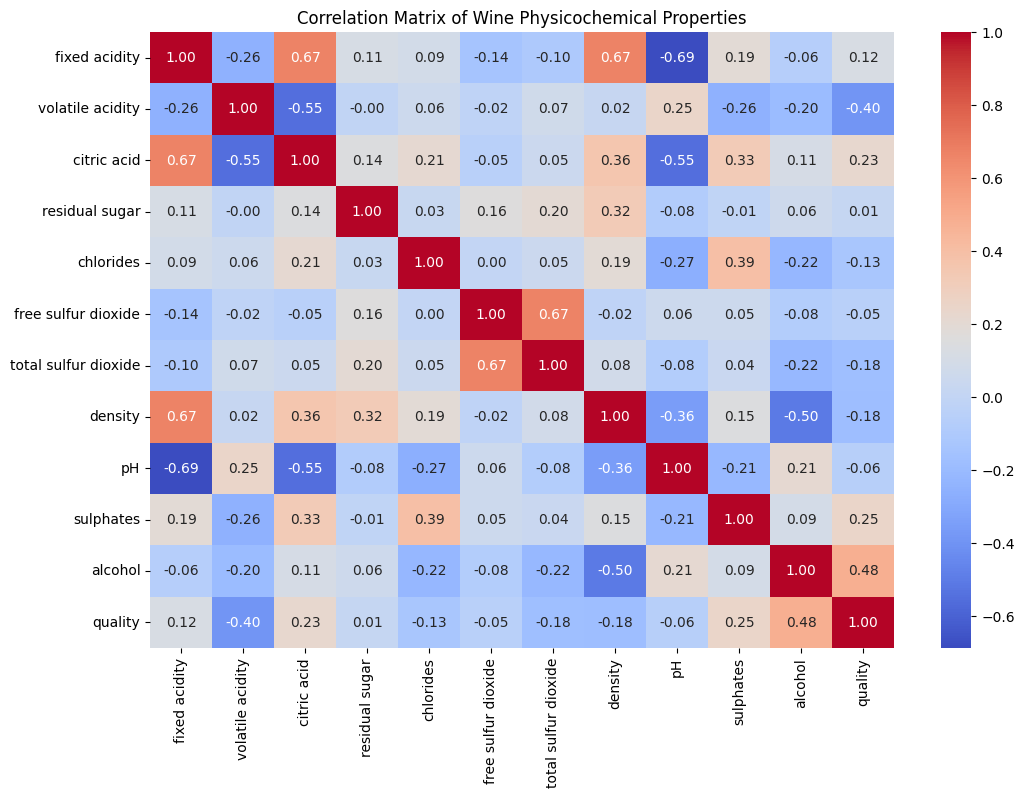

In [ ]:
plt.figure(figsize=(12,8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Wine Physicochemical Properties")

plt.show()

In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## 6. Feature Engineering

### 6.1 Quality Class Creation

The original dataset contains wine quality scores ranging from 3 to 8. For manufacturing quality prediction, the quality scores are converted into two classes. Scores below 6 are considered lower quality, while scores of 6 or above are considered acceptable/good quality.

In [ ]:
df["quality_class"] = df["quality"].apply(
    lambda x: 1 if x >= 6 else 0
)

df[["quality", "quality_class"]].head(10)

,quality,quality_class
0,5,0
1,5,0
2,5,0
3,6,1
5,5,0
6,5,0
7,7,1
8,7,1
9,5,0
10,5,0


In [ ]:
df["quality_class"].value_counts()

,count
quality_class,
1,719
0,640


In [ ]:
df["quality_class"].value_counts(normalize=True) * 100

,proportion
quality_class,
1,52.906549
0,47.093451


### 6.2 Derived Feature Creation

Additional features are created from the original physicochemical properties to capture meaningful relationships between wine characteristics. These derived features are used to provide the machine learning models with additional information for quality prediction.

In [ ]:
# Create derived features

# 1. Sulfur dioxide ratio
df["sulfur_dioxide_ratio"] = (
    df["free sulfur dioxide"] / (df["total sulfur dioxide"] + 1)
)

# 2. Acid balance
df["acid_balance"] = (
    df["fixed acidity"] + df["citric acid"] - df["volatile acidity"]
)

# 3. Alcohol-to-density ratio
df["alcohol_density_ratio"] = (
    df["alcohol"] / df["density"]
)

print("Derived features created successfully!")

print("\nNew features:")
print("1. sulfur_dioxide_ratio")
print("2. acid_balance")
print("3. alcohol_density_ratio")

Derived features created successfully!

New features:
1. sulfur_dioxide_ratio
2. acid_balance
3. alcohol_density_ratio


### 6.2 Feature and Target Separation

In [ ]:
X = df.drop(columns=["quality", "quality_class"])
y = df["quality_class"]

print("Number of input features:", X.shape[1])
print("Target classes:", y.unique())

Number of input features: 14
Target classes: [0 1]


### 6.3 Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1087
Testing samples: 272


## 7. Machine Learning Model Development

### 7.1 Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to make a more reliable classification. In this project, it is used to predict whether a wine sample belongs to the low-quality or good-quality class based on its physicochemical properties.

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
y_pred_rf = rf_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


### 7.2 Random Forest Model Evaluation

In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

Random Forest Performance
-------------------------
Accuracy : 0.7721
Precision: 0.7929
Recall   : 0.7708
F1 Score : 0.7817


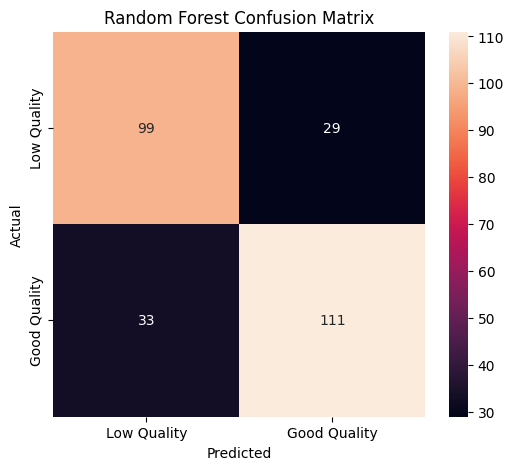

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["Low Quality", "Good Quality"],
    yticklabels=["Low Quality", "Good Quality"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### 7.3 XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is an ensemble machine learning algorithm that builds decision trees sequentially, where each new tree attempts to correct errors made by previous trees. In this project, XGBoost is used to predict whether a wine sample belongs to the low-quality or good-quality class.

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost predictions generated successfully!")

XGBoost predictions generated successfully!


In [ ]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print("XGBoost Performance")
print("-------------------")
print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1 Score :", round(xgb_f1, 4))

XGBoost Performance
-------------------
Accuracy : 0.7426
Precision: 0.7681
Recall   : 0.7361
F1 Score : 0.7518


## 8. Model Comparison
## Model Comparison After Feature Engineering

After feature engineering, Random Forest and XGBoost were trained using the original physicochemical properties along with the three derived features. Random Forest achieved better performance than XGBoost across the evaluated metrics.

Random Forest achieved an accuracy of 77.21% and an F1-score of 78.17%, while XGBoost achieved an accuracy of 74.26% and an F1-score of 75.18%.

Therefore, Random Forest was selected as the final model for wine quality prediction.

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [0.7721, 0.7426],
    "Precision": [0.7929, 0.7681],
    "Recall": [0.7708, 0.7361],
    "F1 Score": [0.7817, 0.7518]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.7721,0.7929,0.7708,0.7817
1,XGBoost,0.7426,0.7681,0.7361,0.7518


In [15]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_scores[0], xgb_scores[0]],
    "Precision": [rf_scores[1], xgb_scores[1]],
    "Recall": [rf_scores[2], xgb_scores[2]],
    "F1 Score": [rf_scores[3], xgb_scores[3]]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.7721,0.7929,0.7708,0.7817
1,XGBoost,0.7426,0.7681,0.7361,0.7518


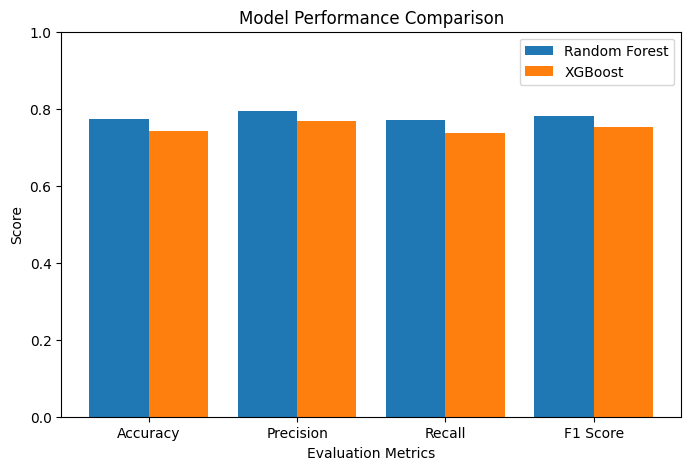

In [12]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

rf_scores = [0.7721, 0.7929, 0.7708, 0.7817]
xgb_scores = [0.7426, 0.7681, 0.7361, 0.7518]

x = range(len(metrics))

plt.figure(figsize=(8, 5))

plt.bar([i - 0.2 for i in x], rf_scores, width=0.4, label="Random Forest")
plt.bar([i + 0.2 for i in x], xgb_scores, width=0.4, label="XGBoost")

plt.xticks(list(x), metrics)
plt.ylabel("Score")
plt.xlabel("Evaluation Metrics")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.legend()

# Save the completed graph
plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

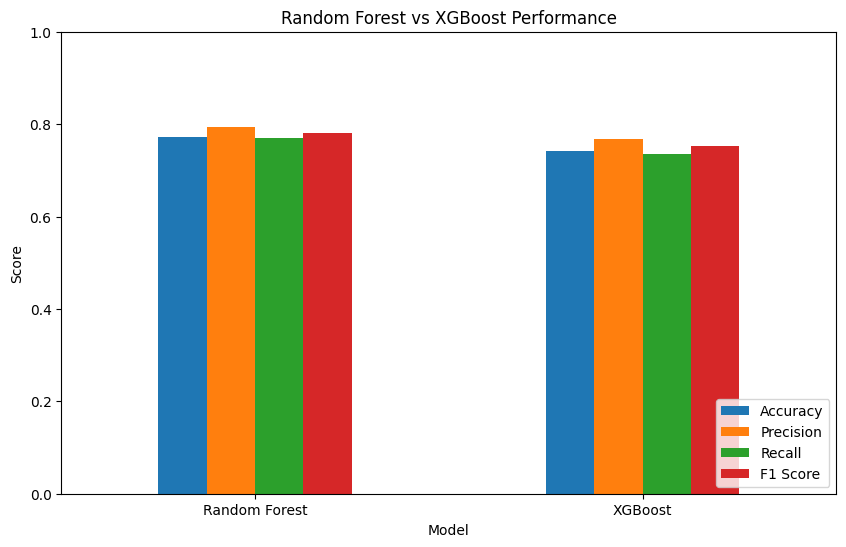

In [16]:
results_plot = results.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Random Forest vs XGBoost Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.legend(loc="lower right")
plt.show()

## 9. Feature Importance

Feature importance is used to identify which physicochemical properties contribute most to the prediction of wine quality. This helps interpret the machine learning model and provides useful information for manufacturing quality control.

In [ ]:
# Feature Importance - Random Forest

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
display(feature_importance)

Feature Importance:


,Feature,Importance
13,alcohol_density_ratio,0.150072
10,alcohol,0.120091
9,sulphates,0.096593
1,volatile acidity,0.086402
6,total sulfur dioxide,0.067894
11,sulfur_dioxide_ratio,0.063425
12,acid_balance,0.060211
7,density,0.059181
4,chlorides,0.054763
8,pH,0.051418


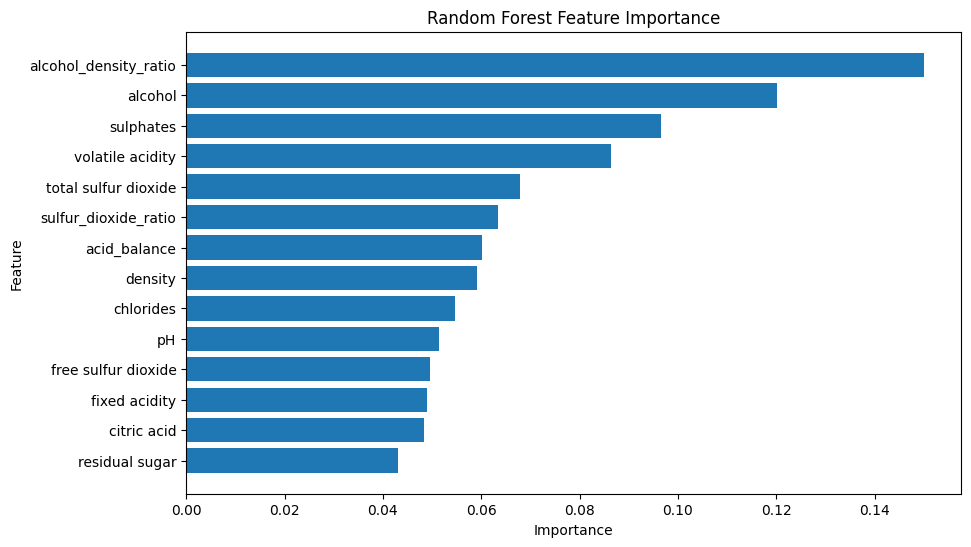

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.show()

In [ ]:
top_5_features = feature_importance.head(5)

print("Top 5 Important Features:")
display(top_5_features)

Top 5 Important Features:


,Feature,Importance
13,alcohol_density_ratio,0.150072
10,alcohol,0.120091
9,sulphates,0.096593
1,volatile acidity,0.086402
6,total sulfur dioxide,0.067894


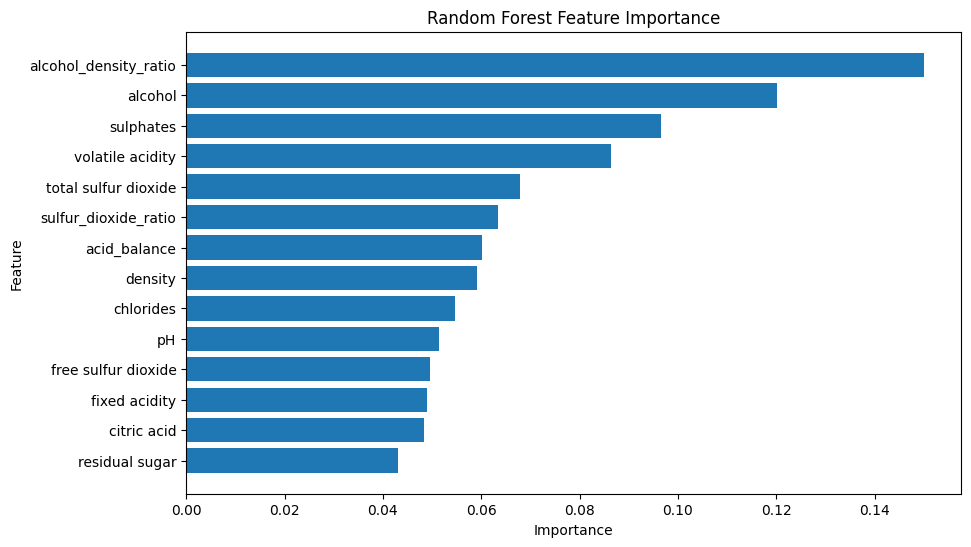

In [18]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

# Save the graph
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

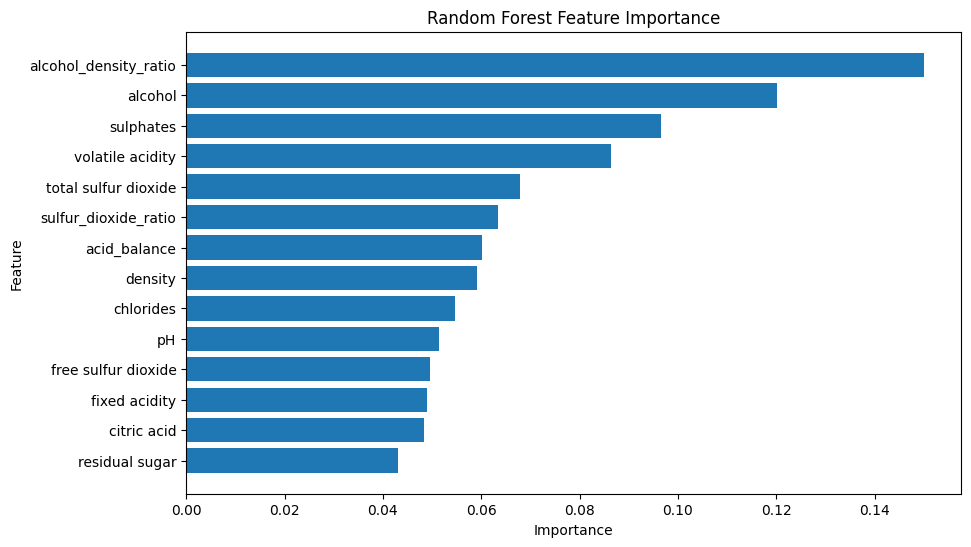

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import os # New import
import requests # New import

# --- Re-defining dependencies for standalone execution ---
# Ensure the dataset is available
file_path = "/content/winequality-red.csv"
if not os.path.exists(file_path):
    print(f"File not found at {file_path}. Attempting to download.")
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
    try:
        r = requests.get(url)
        r.raise_for_status() # Raise HTTPError for bad responses (4xx or 5xx)
        with open(file_path, 'wb') as f:
            f.write(r.content)
        print(f"Downloaded {url} to {file_path}")
    except requests.exceptions.RequestException as e:
        print(f"Failed to download file from {url}. Error: {e}")

# Load Data
df = pd.read_csv(file_path, sep=";")

# Clean Data
df = df.drop_duplicates()

# Feature Engineering (Quality Class)
df["quality_class"] = df["quality"].apply(lambda x: 1 if x >= 6 else 0)

# Derived Features (for consistency with original notebook)
df["sulfur_dioxide_ratio"] = df["free sulfur dioxide"] / (df["total sulfur dioxide"] + 1)
df["acid_balance"] = df["fixed acidity"] + df["citric acid"] - df["volatile acidity"]
df["alcohol_density_ratio"] = df["alcohol"] / df["density"]

# Separate Features and Target
X = df.drop(columns=["quality", "quality_class"])
y = df["quality_class"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Define and Train Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train, y_train)
# --- End of re-defining dependencies ---

# Calculate Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

# Save the graph
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

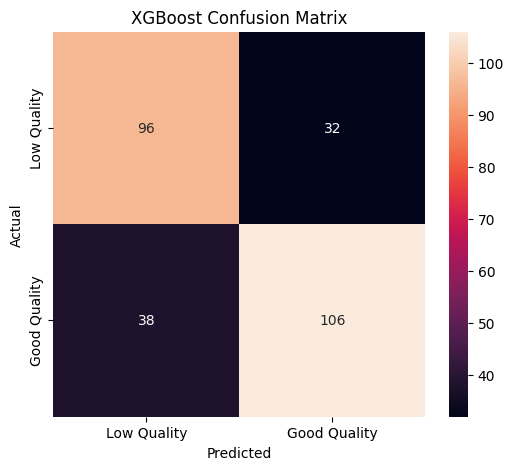

In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    xticklabels=["Low Quality", "Good Quality"],
    yticklabels=["Low Quality", "Good Quality"]
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 10. Final Wine Quality Prediction

The trained Random Forest model is used to predict the quality class of a new wine sample based on its 11 physicochemical properties.

In [ ]:
def predict_wine_quality(
    fixed_acidity,
    volatile_acidity,
    citric_acid,
    residual_sugar,
    chlorides,
    free_sulfur_dioxide,
    total_sulfur_dioxide,
    density,
    pH,
    sulphates,
    alcohol
):

    new_sample = pd.DataFrame([[
        fixed_acidity,
        volatile_acidity,
        citric_acid,
        residual_sugar,
        chlorides,
        free_sulfur_dioxide,
        total_sulfur_dioxide,
        density,
        pH,
        sulphates,
        alcohol
    ]], columns=X.columns)

    prediction = rf_model.predict(new_sample)[0]

    if prediction == 1:
        return "Good Quality"
    else:
        return "Low Quality"

In [ ]:
prediction = predict_wine_quality(
    fixed_acidity=7.5,
    volatile_acidity=0.50,
    citric_acid=0.30,
    residual_sugar=2.0,
    chlorides=0.07,
    free_sulfur_dioxide=20,
    total_sulfur_dioxide=50,
    density=0.996,
    pH=3.3,
    sulphates=0.70,
    alcohol=10.5
)

print("Predicted Wine Quality:", prediction)

Predicted Wine Quality: Good Quality


## 11. Final Model Selection

Random Forest and XGBoost were evaluated using accuracy, precision, recall, and F1-score. Based on the evaluation results, Random Forest achieved better overall performance than XGBoost. Therefore, Random Forest was selected as the final model for wine quality classification.

In [ ]:
best_model = rf_model

print("Selected Final Model: Random Forest")
print("Accuracy:", round(rf_accuracy * 100, 2), "%")
print("F1 Score:", round(rf_f1 * 100, 2), "%")

## 12. Manufacturing Interpretation

The developed system can support wine manufacturing quality control by predicting whether a wine sample is likely to meet the defined quality level based on its physicochemical properties. The feature importance analysis identified alcohol, sulphates, volatile acidity, total sulfur dioxide, and density as the most influential parameters for the Random Forest model. Monitoring these parameters can help manufacturers identify potentially lower-quality batches and support timely quality-control decisions.

# Conclusion

This project developed a machine learning-based wine quality prediction system using physicochemical properties. Data preprocessing and feature engineering were performed to prepare the dataset for classification. Three derived features were created: sulfur dioxide ratio, acid balance, and alcohol-to-density ratio.

Random Forest and XGBoost were developed and evaluated. After feature engineering, Random Forest achieved an accuracy of 77.21% and an F1-score of 78.17%, outperforming XGBoost, which achieved an accuracy of 74.26% and an F1-score of 75.18%. Therefore, Random Forest was selected as the final model.

The final prediction system can classify a wine sample as Good Quality or Low Quality based on its physicochemical properties. Feature importance analysis also helps identify the parameters that have the greatest influence on the prediction, supporting data-driven quality monitoring in wine manufacturing.